### CS4423 - Networks
Prof. Götz Pfeiffer<br />
School of Mathematics, Statistics and Applied Mathematics<br />
NUI Galway


**Name:** Cian Mac Liatháin

**ID:** 11476078

# Assignment 1

Provide answers to the problems in the boxes provided.  Partial marks will be awarded for
participation and engagement.

When finished, print this notebook into a **pdf** file and submit this to
**blackboard**.

**Deadline** is next Monday at 5pm.

## Setup

This is a `jupyter` notebook.   You can open and interact
with the notebook through one of sites recommended at
its [github](https://github.com/gpfeiffer/cs4423) repository.

Or, you can
install and use `jupyter` as a `python` package on your own laptop or PC.  

The following command loads the `networkx` package into the current session.  
The next command specifies some standard options that can be useful for drawing graphs.  

In order to execute the code in a box,
use the mouse or arrow keys to highlight the box and then press SHIFT-RETURN.

In [1]:
import networkx as nx
opts = { "with_labels": True, "node_color": 'y', "font_color" : 'r' }

Should it ever happen that the notebook becomes unusable, start again with a fresh copy.

##  1. Warmup.

The purpose of this task is to get you used to working with the `networkx` package
in the `jupyter` notebook environment.

1. Define a new (simple) graph `G` on the vertex set $X = \{0, 1, 2, 3, 4, 5, 6, 7, 8, 9\}$
with edges $0-1$, $1-2$, $2-3$, $3-4$, $4-5$, $5-6$, $6-7$, $7-8$, $8-9$, and $9-0$.
Draw the graph.  Hence or otherwise determine its **order** (the number of nodes)
and its **size** (the number of links).

Order: 10
Size: 10


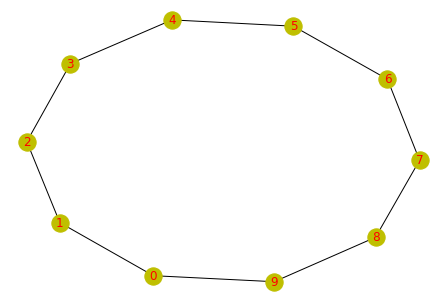

In [2]:
#1.1

#Define graph from edges
G = nx.Graph(["01", "12", "23", "34","45","56","67","78","89","90"])
nx.draw(G,**opts)

#Determine its order
print("Order:", G.order())


#Determine its size
print("Size:", G.size())

2. Find the **adjacency matrix** $A$ of the graph `G`.  Then compute its square, $A^2$,
and draw the graph `G2` that has $A^2$ as its adjacency matrix.  What are the connected components of `G2`? 

In [3]:
#Find scipy sparse matrix
A = nx.adjacency_matrix(G)

#Convert to numpy array
A = A.toarray()
print(A)


[[0. 1. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


In [4]:
#Compute its square
AA = (A@A).toarray()
print(AA)

#Draw graph G2 from AA
G2 = nx.Graph(AA)
nx.draw(G2, **opts)

AttributeError: 'numpy.ndarray' object has no attribute 'toarray'

In [ ]:
#Connected components of G2
list(nx.connected_components(G2))

The connected components of the squared adjacency matrix indicate the nodes in G that are connected by a path of length 2

##  2.  Projections

Suppose that $G$ is a bipartite graph on a vertex set that is the disjoint union of two sets $X$ and $Y$, where each edge
connects a verte in $X$ to a vertex in $Y$.  The **projection** of $G$ onto the set $X$
is the graph with vertex set $X$, where any two elements are joined by an edge whenever
they are joined to a common element $y \in Y$ in the graph $G$.  
The adjacency matrix of the projection can be derived from the square $A^2$ of the adjacency matrix
$A$ of $G$.

Consider the affilliation network below, with $11$ people labelled $A$ to $K$,
and four foci labelled $1$, $2$, $3$ and $4$, 



1.  Compute the adjacency matrix of $G$.

2. Draw the projection on (just)
   the people, in which two people are joined by an edge if they have a common
   focus.
   (Of course, one can do this easily by hand.  It would be nice to get
   `networkx` to do it for you.)

3. Compute the adjacency matrix $B$ of the projection
   and compare it to $A^2$.  What do you observe?

In [ ]:
# Q.2 Recreate the graph
G = nx.Graph()

# Identify two sets of nodes
bottom = ['A','B','C','D','E','F','G','H','I','J','K']
top = [1,2,3,4]

# List the edges from the diagram
edges = [(1,'A'),(1,'B'),(1,'C'),(1,'D'),(2,'A'),(2,'D'),(2,'E'),(2,'F'),(2,'G'),(3,'E'),(3,'F'),(3,'H'),(3,'I'),(4,'G'),(4,'J'),(4,'K')] 

# Create graph from nodes
G.add_nodes_from(bottom)
G.add_nodes_from(top)
G.add_edges_from(edges)

# Add bipartite attributes
G.graph['top'] = top
G.graph['bottom'] = bottom

# Generate co-ordinates for each vertex
pos1 = {n:(0,top.index(n)*1.5) for n in top}
pos2 = {n:(1,bottom.index(n)/2) for n in bottom}
pos = {**pos1, **pos2}


# Colour based on x co-ordinate
color = [pos[x][0] for x in G.nodes()]
opts2 = { "with_labels": True, "node_color": color, "font_color": 'r' }

# Draw graph
nx.draw(G, pos, **opts2)

In [ ]:
#2.1 Calculate adjacency matrix of G
A = nx.adjacency_matrix(G)
print(A.toarray())

We can see that the adjacency matrix A is of the form $\begin{pmatrix} 0 & C \\ C^T & 0 \end{pmatrix}$

In the first row, the first {{len(bottom)}} values are 0 as there are no edges between the set of people (bipartite), and the values of 1 represent the edges between person A and focus 1 and 2.


In [ ]:
#2.2 Projection on (just) the people
B_proj = nx.projected_graph(G, bottom)
nx.draw(B_proj, **opts)


In [ ]:
#2.3 Adjacency comparison

#a. Calculate adjacency matrix B of the projection
B_adj = nx.adjacency_matrix(B_proj)
print(B_adj.toarray())

In [ ]:
#b. Calculate the square of the adjacency matrix of G
AA = (A @ A).toarray()
print(AA)

We can see that the adjacency matrix B indicates the connected vertices of the projection: the people who share a common focus in G are connected in the projection.

There exists a path of length 2 in G between all people nodes who share a common focus.

Similarly, the squared adjacency matrix AA indicates the number of walks from i to j of length 2.

The square matrix can be converted to an adjacency matrix of the projection by removing the walks of length 2 from i to i (the diagonal) Also by indicating whether a path of length 2 exists rather than counting them by making all values > 1, equal to 1.

In [ ]:
# Turn A squared into an adjacency matrix
AA[AA>1] = 1
np.fill_diagonal(AA,0)
print(AA)

This adjacency matrix is in the form $\begin{pmatrix} CC^T & 0 \\ 0 & C^TC \end{pmatrix}$ 

We can see the projection B in this adjacency matrix, calculated by $CC^T$.
We also see the projection of G onto the set of foci, $C^TC$. 

## 3. Random Trees

The `nx.random_tree(n)` command can be used to generate a random tree on the `n` vertices
represented in `python` by `range(n)`.

Such a tree can be converted into a sequence of $n - 2$ numbers, its **Prüfer code** by the
`python` function `pruefer_code`, defined as follows:

In [7]:
def pruefer_node(tree):
    for x in tree:
        if tree.degree(x) == 1:
            for y in tree[x]:
                tree.remove_node(x)
                return y

def pruefer_code(T):
    tree = T.copy()
    return [pruefer_node(tree) for k in range(tree.order() - 2)]

In [ ]:
T = nx.random_tree(12)

In [ ]:
code = pruefer_code(T)
code

In [8]:
T = nx.Graph(["13","23","34","45"])
pruefer_code(T)

['3', '3', '4']

Conversely, the following function `tree_pruefer` constructs a tree from a
Prüfer code.

In [10]:
def tree_pruefer(code):

    # initialize graph and defects
    n = len(code) + 2
    tree = nx.empty_graph(n)
    degrees = [1 for x in tree]

    for y in code:
        degrees[y] += 1
        
    # add edges
    for y in code:
        for x in tree:
            if degrees[x] == 1:
                tree.add_edge(x, y)
                for z in (x, y):
                    degrees[z] -= 1
                break
                
    # final edge
    e = [x for x in tree if degrees[x] == 1]
    tree.add_edge(*e)
    
    return tree

1. Construct a few random trees on $n = 10, 11, 12, \ldots$ nodes.  For each such tree,
   draw it, compute its Prüfer code and then convert the code back into a tree.
   Do you get your old tree back?

2. For a few randomly chosen Prüfer codes, construct the corresponding tree, 
   draw it if you want, and convert it back into a Prüfer code.
   Do you get your old code back?
   
3. Which tree on $n$ nodes corresponds to the Prüfer code 
   consisting of $n-2$ entries $0$?

In [ ]:
#3.1 Pruefer practice
T1 = nx.random_tree(10)
nx.draw(T1, **opts)

In [ ]:
pcode1 = pruefer_code(T1)
print(pcode1)

nx.draw(tree_pruefer(pcode1), **opts)

In [ ]:
T2 = nx.random_tree(14)
nx.draw(T2, **opts)

In [ ]:
pcode2 = pruefer_code(T2)
print(pcode2)
nx.draw(tree_pruefer(pcode2), **opts)

**3.1 Do you get your old tree back?**

We can see that the tree_pruefer function reconstructs the original tree from the pruefer code. The length of the pruefer code indicates the original number of nodes - 2, and the frequency that each node is found in the pruefer code represents its original degree - 1, those nodes not found in the code had degree of 1. This information preserved in the pruefer code can then be used to reconstruct the original tree.

In [ ]:
np.random.randint(n,size=n-2)

In [ ]:
#3.2 Pruefer re/deconstruction

pcode3 = [1, 3, 1, 2]
T3 = tree_pruefer(pcode3)
nx.draw(T3, **opts)

In [ ]:
print(pruefer_code(T3))

In [ ]:
pcode4 = [5, 6, 6, 9, 11, 6, 1, 2, 9, 11]
T4 = tree_pruefer(pcode4)

nx.draw(T4, **opts)

In [18]:
T_Test = tree_pruefer([1,2,3])

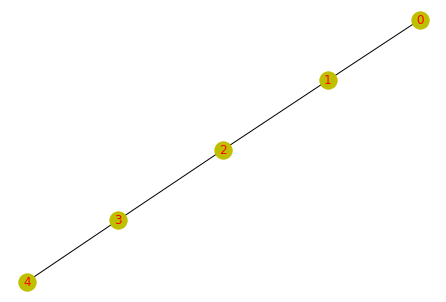

In [19]:
nx.draw(T_Test, **opts)

In [ ]:
print(pruefer_code(T4))

**3.2 Do you get your old code back?**

We can see that the pruefer_code function successfully converts the tree into the same pruefer code, by listing the parent node of the lowest order leaf, removing that leaf and proceeding through the graph until 2 node remain.

**3.3 Which tree on n nodes corresponds to the Pruefer code consisting of n-2 entries 0?**

Any tree with only one central node 0 of degree n - 1 and all other nodes being leaves of degree 1.

In [ ]:
# 3.3 Example trees

nx.draw(tree_pruefer([0,0,0,0]), **opts)

In [ ]:
nx.draw(tree_pruefer([0,0,0]), **opts)

In [ ]:
nx.draw(tree_pruefer([0,0,0,0,0,0,0,0]), **opts)

## 4. Breadth First Search.

Breadth First Search (BFS) is a versatile and efficient strategy for systematically visiting
all the nodes in a graph.

Given a graph $G = (X, E)$ and a starting point $x \in X$, BFS can be described as the following sequence of steps.

1. mark all nodes of $G$ as "unseen".

2. initialize a list `seen = [x]` and mark `x` as seen.

3. loop over the elements `y` in the list `seen` and, in each step, visit the
   node `y` and add all of `y`'s neighbors that have not been marked as "seen"
   to the list `seen` and mark them as seen.


### For Example

Consider the graph on the vertex set `"ABCDEFGHIJ"`
defined in the nearby file `data/bfs.adj` by adjacency lists.

In [ ]:
G = nx.read_adjlist("data/bfs.adj")
nx.draw(G, **opts)

Let's say we want to start exploring the graph at vertex `'A'`

In [ ]:
x = 'A'

**Step 1.** For each of its nodes `x`, the graph object `G` maintains in `G.nodes[x]` a `python` dictionary
that can be used store arbirary attributes of the nodes.  We can use it for an attribute `'seen'`,
which is set to `True` or `False`, depending on whether the node has already been seen by this instance 
of BFS, or not.  Initially it would be false for all nodes.

In [ ]:
G.nodes[x]

In [ ]:
for y in G:
    G.nodes[y]['seen'] = False

**Step 2.** Initialize a `python` list `seen` to contain `x` only, and set `x`'s `'seen'` attribute to `True`.

In [ ]:
seen = [x]
G.nodes[x]['seen'] = True

**Step 3.**  The loop over `seen`.  For each node `y` in the list, print `y`, then
add all of `y`'s unseen neighbors to the end of the list `seen` and mark them
as `"seen"`.  Note how the list `seen` initially has only one element, but grows
over time, until no more new nodes are detected.  
The loop automatically terminates when the end of the list `seen` has been reached.

In [ ]:
for y in seen:
    print(y)
    for z in G.neighbors(y):
        if not G.nodes[z]['seen']:
            seen.append(z)
            G.nodes[z]['seen'] = True

In a variant of the same BFS strategy, on can construct a tree on the vertex set $X$ that
records the history of how the nodes in the graph $G$ were discovered.

In [ ]:
x = 'A'

We set up an empty graph `T` to eventually contain the tree.

In [ ]:
T = nx.Graph()

From here it's essentially the same procedure as above ...

In [ ]:
for y in G:
    G.nodes[y]['seen'] = False

... except that we need to add the initial vertex `x` to `T` ...

In [ ]:
T.add_node(x)
seen = [x]
G.nodes[x]['seen'] = True

... and instead of printing `y`, we add the edges leading to `y`'s children to the tree `T`.

In [ ]:
for y in seen:
    for z in G.neighbors(y):
        if not G.nodes[z]['seen']:
            T.add_edge(y, z)
            seen.append(z)
            G.nodes[z]['seen'] = True

The resulting tree `T` is called a **spanning tree** of the graph `G`.

In [ ]:
nx.draw(T, **opts)

1. Print out all the nodes of $G$ as discovered when the starting point is node `J`.
2. Construct a spanning tree of the graph `$G$ with node `J` as starting point.
3. Repeat 1 and 2 for one more starting node.
4. Is there a sense of distance between nodes that becomes apparent through these traversals?
   Could a variant of BFS be used to compute such distances between nodes in $G$?

In [ ]:
#4.1 Print nodes of G as discovered from 'J'
def bfs(graph, start_node):
    for y in graph:
        graph.nodes[y]['seen'] = False
    
    graph.nodes[start_node]['seen'] = True
    
    seen = [start_node]
    
    for y in seen:
        for z in G.neighbors(y):
            if not G.nodes[z]['seen']:
                seen.append(z)
                G.nodes[z]['seen'] = True
    return seen

bfs(G, 'J')

In [ ]:
#4.2 Construct a spanning tree of G starting at node 'J'

def spanning_tree(graph, start_node):
    for y in graph:
        graph.nodes[y]['seen'] = False
        
    T = nx.Graph()
    T.add_node(start_node)
    
    seen = [start_node]
    graph.nodes[start_node]['seen'] = True
    
    for y in seen:
        for z in graph.neighbors(y):
            if not graph.nodes[z]['seen']:
                T.add_edge(y,z)
                seen.append(z)
                graph.nodes[z]['seen'] = True
    print(T.nodes())
    return T  

nx.draw(spanning_tree(G, 'J'), **opts)


In [ ]:
#4.3 Nodes and tree for another node

bfs(G, 'C')
nx.draw(spanning_tree(G, 'C'), **opts)

**4.4 Distance? Variant of BFS?**
The way breadth first search is designed, it visits all neighbours distance 1 away from the starting node, and then proceeds to visit all neighbours distance 1 away from each of these nodes before proceeding. 

By keeping track of the parent of each node we can easily return the distance between them if needed.

In [ ]:
def bfs2(user_graph, start_node, end_node = ''):
    graph = user_graph.copy()
    
    for y in graph:
        graph.nodes[y]['seen'] = False   # Set all nodes as unseen
        graph.nodes[y]['parent'] = ''    # Set all nodes parents as unknown                

    graph.nodes[start_node]['seen'] = True     #Set start node as seen
    seen = [start_node]
 
    
    for y in seen:

        for z in graph.neighbors(y):
            if not graph.nodes[z]['seen']:     #Check if neighbour is seen before
                seen.append(z)
                graph.nodes[z]['seen'] = True  #Set neighbour as seen
                graph.nodes[z]['parent'] = y   #Record node's parent when first seen
    
    # Trace back distance (if end_node given)
    if end_node != '':
        
        counter=0
        trace = end_node
        while trace != start_node:
            trace = graph.nodes[trace]['parent']
            counter=counter+1
        
        return seen, counter
    
    else: 
        return seen
    

In [ ]:
bfs2(G,'B')

In [ ]:
bfs2(G, 'K', 'F')

In [ ]:
nodes, distance = bfs2(G, 'C', 'J')
print("Nodes: ", nodes)
print("Distance:", distance)